In [4]:
import pandas as pd
df = pd.read_csv("Mercenaries.currency.csv", sep=";")
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43126 entries, 0 to 43125
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   League      43126 non-null  object 
 1   Date        43126 non-null  object 
 2   Get         43126 non-null  object 
 3   Pay         43126 non-null  object 
 4   Value       43126 non-null  float64
 5   Confidence  43126 non-null  object 
dtypes: float64(1), object(5)
memory usage: 2.0+ MB


,Value
count,43126.000000
mean,839.433676
std,10934.188782
min,0.000000
25%,0.142860
50%,2.179335
75%,30.000000
max,402500.000000


        League       Date            Get        Pay    Value Confidence
0  Mercenaries 2025-06-13  Chromatic Orb  Chaos Orb  0.16667       High
1  Mercenaries 2025-06-14  Chromatic Orb  Chaos Orb  0.15385       High
2  Mercenaries 2025-06-15  Chromatic Orb  Chaos Orb  0.23810       High
3  Mercenaries 2025-06-16  Chromatic Orb  Chaos Orb  0.17768       High
4  Mercenaries 2025-06-17  Chromatic Orb  Chaos Orb  0.16129       High
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43126 entries, 0 to 43125
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   League      43126 non-null  object        
 1   Date        43126 non-null  datetime64[ns]
 2   Get         43126 non-null  object        
 3   Pay         43126 non-null  object        
 4   Value       43126 non-null  float64       
 5   Confidence  43126 non-null  object        
dtypes: datetime64[ns](1), float64(1), object(4)
memory usage: 2.0+ MB
None


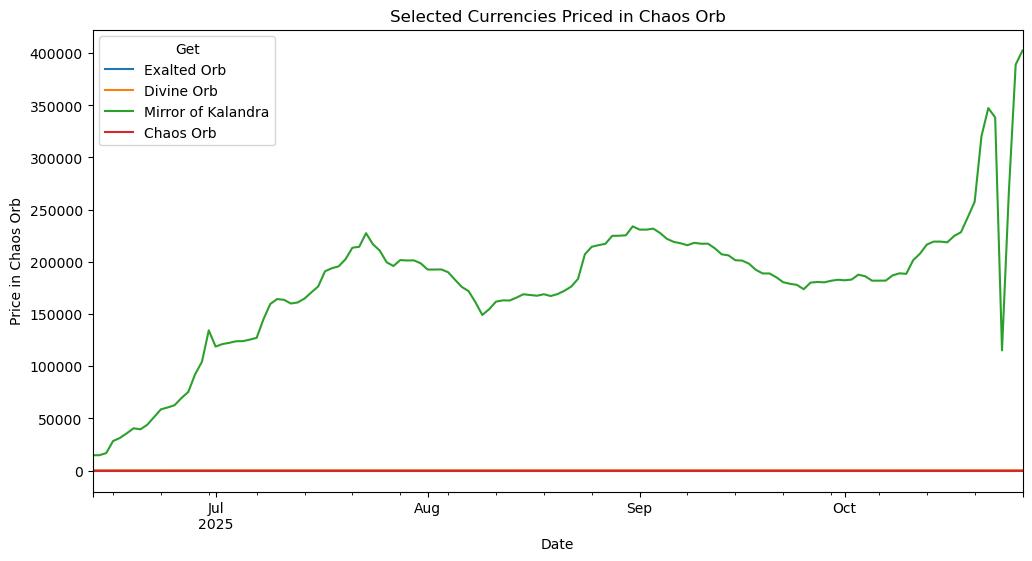

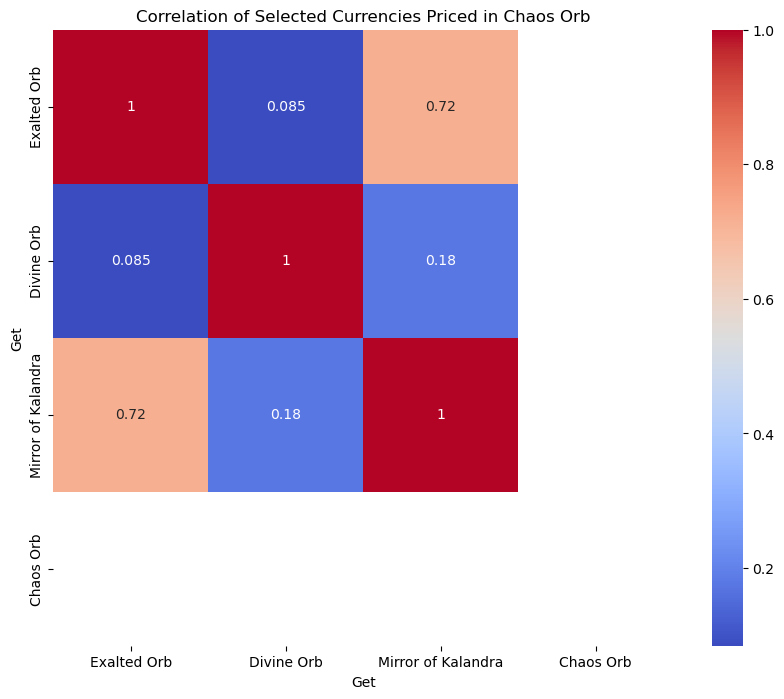

                          Currency  Cluster
0                Abrasive Catalyst        0
126                  Ritual Vessel        0
127                 Rogue's Marker        0
128                 Sacred Blossom        0
129  Sacred Crystallised Lifeforce        0
..                             ...      ...
71            Glassblower's Bauble        0
62        Fragment of Purification        0
198                      Chaos Orb        0
92              Mirror of Kalandra        1
54         Forgotten Reliquary Key        2

[199 rows x 2 columns]


C:\Users\Nemo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


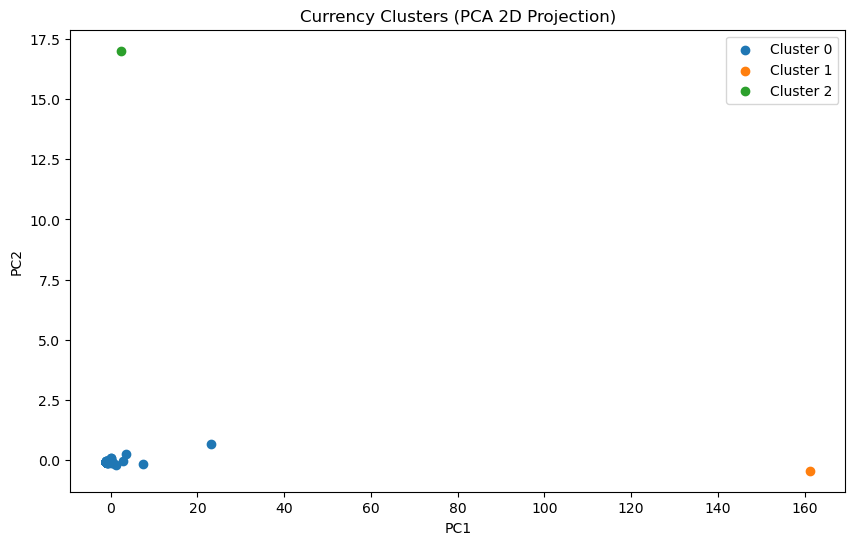

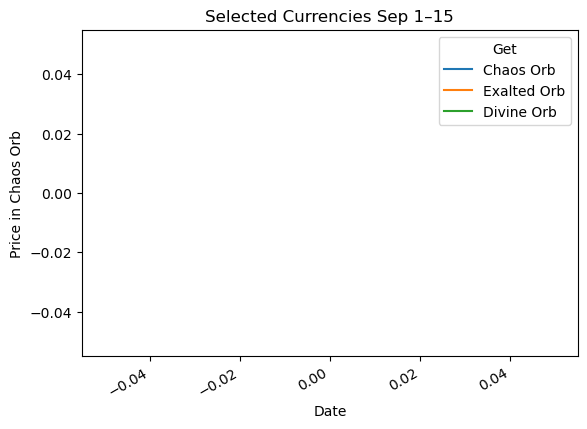

In [24]:
# PoE Economy M2 Analysis - Owen Williams
# CS4412: Data Mining

# ------------------------------
# 1. IMPORT LIBRARIES
# ------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# ------------------------------
# 2. LOAD DATA
# ------------------------------
df = pd.read_csv("Mercenaries.currency.csv", sep=';')  # ; delimiter

# Convert Date to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Quick overview
print(df.head())
print(df.info())
print(df.describe())

# ------------------------------
# 3. HANDLE DUPLICATES
# ------------------------------
# Check duplicates based on Date + Get + Pay
duplicates = df[df.duplicated(subset=['Date','Get','Pay'], keep=False)]
print("Duplicate rows:\n", duplicates)

# Aggregate duplicates by mean
df = df.groupby(['Date','Get','Pay'], as_index=False)['Value'].mean()

# ------------------------------
# 4. FILTER FOR PAY = CHAOS ORB
# ------------------------------
chaos_pairs = df[df['Pay'] == 'Chaos Orb'].copy()

# ------------------------------
# 5. CREATE PIVOT TABLE (GET CURRENCIES AS COLUMNS)
# ------------------------------
pivot = chaos_pairs.pivot_table(
    index='Date',
    columns='Get',
    values='Value',
    aggfunc='mean'
)

# ------------------------------
# 6. HANDLE MISSING VALUES
# ------------------------------
# Fill missing values forward then backward
pivot = pivot.ffill().bfill()

# Optional: check remaining NaNs
print(pivot.isna().sum())

# ------------------------------
# 7. ADD CHAOS ORB BASELINE
# ------------------------------
# Chaos Orb = 1 Chaos Orb per Chaos Orb
pivot['Chaos Orb'] = 1

# ------------------------------
# 8. VISUALIZE SELECTED CURRENCIES
# ------------------------------
currencies_to_plot = ['Exalted Orb', 'Divine Orb', 'Mirror of Kalandra', 'Chaos Orb']
pivot[currencies_to_plot].plot(figsize=(12,6), title="Selected Currencies Priced in Chaos Orb")
plt.ylabel("Price in Chaos Orb")
plt.xlabel("Date")
plt.show()

# ------------------------------
# 9. CORRELATION HEATMAP
# ------------------------------
plt.figure(figsize=(10,8))
sns.heatmap(pivot[currencies_to_plot].corr(), cmap='coolwarm', annot=True)
plt.title("Correlation of Selected Currencies Priced in Chaos Orb")
plt.show()

# ------------------------------
# 10. SCALE DATA FOR CLUSTERING
# ------------------------------
scaler = StandardScaler()
scaled = scaler.fit_transform(pivot.T)  # transpose so rows = currencies

# ------------------------------
# 11. APPLY K-MEANS CLUSTERING
# ------------------------------
k = 3  # number of clusters, adjust as needed
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(scaled)

# ------------------------------
# 12. ASSIGN CLUSTERS TO CURRENCIES
# ------------------------------
currency_clusters = pd.DataFrame({'Currency': pivot.columns, 'Cluster': clusters})
print(currency_clusters.sort_values('Cluster'))

# ------------------------------
# 13. OPTIONAL: PLOT CLUSTERS (2D PCA)
# ------------------------------
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled)

plt.figure(figsize=(10,6))
for cluster in range(k):
    plt.scatter(
        pca_result[clusters == cluster, 0],
        pca_result[clusters == cluster, 1],
        label=f'Cluster {cluster}'
    )
plt.title("Currency Clusters (PCA 2D Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()

# ------------------------------
# 14. EXAMINE SPECIFIC TIME PERIOD
# ------------------------------
# Example: Chaos Orb behavior early September
subset = pivot.loc['2023-09-01':'2023-09-15', ['Chaos Orb','Exalted Orb', 'Divine Orb']]
subset.plot(title="Selected Currencies Sep 1–15")
plt.ylabel("Price in Chaos Orb")
plt.show()